# 🛠️ Preparação dos Dados

### Extração de dados tratados

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv("https://raw.githubusercontent.com/LeticiaSFMachado/Challenge-Alura-TelecomX_BR-pt2/refs/heads/main/dados_tratados.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


### Remoção da coluna "customerID"

In [57]:
df = df.drop("customerID", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [58]:
df['Churn'] = df['Churn'].str.strip().map({'Yes': 1, 'No': 0})
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


### Tranformando as variáveis categóricas em valores numéricos.

In [59]:
colunas_categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService',
                       'MultipleLines', 'InternetService', 'OnlineSecurity',
                       'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract',
                       'PaperlessBilling', 'PaymentMethod']
df_encoded = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

### Verificação da proporção de evasão de clientes.

In [60]:
# Contagem de classe 'Churn'
churn_counts = df_encoded['Churn'].value_counts()

# Calculando proporcão
churn_proportions = df_encoded['Churn'].value_counts(normalize=True) * 100

print("Contagem de clientes por classe de Churn:")
print(churn_counts)
print("\nProporção de clientes por classe de Churn (%):")
print(churn_proportions)

# Avaliando o desequilíbrio
if churn_proportions.min() < 25:
    print("\nAtenção: Há um desequilíbrio significativo entre as classes de Churn.")
else:
    print("\nAs classes de Churn estão relativamente equilibradas.")

Contagem de clientes por classe de Churn:
Churn
0    5163
1    1869
Name: count, dtype: int64

Proporção de clientes por classe de Churn (%):
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

As classes de Churn estão relativamente equilibradas.


# 🎯 Correlação e Seleção de Variáveis

### Análise de correlação

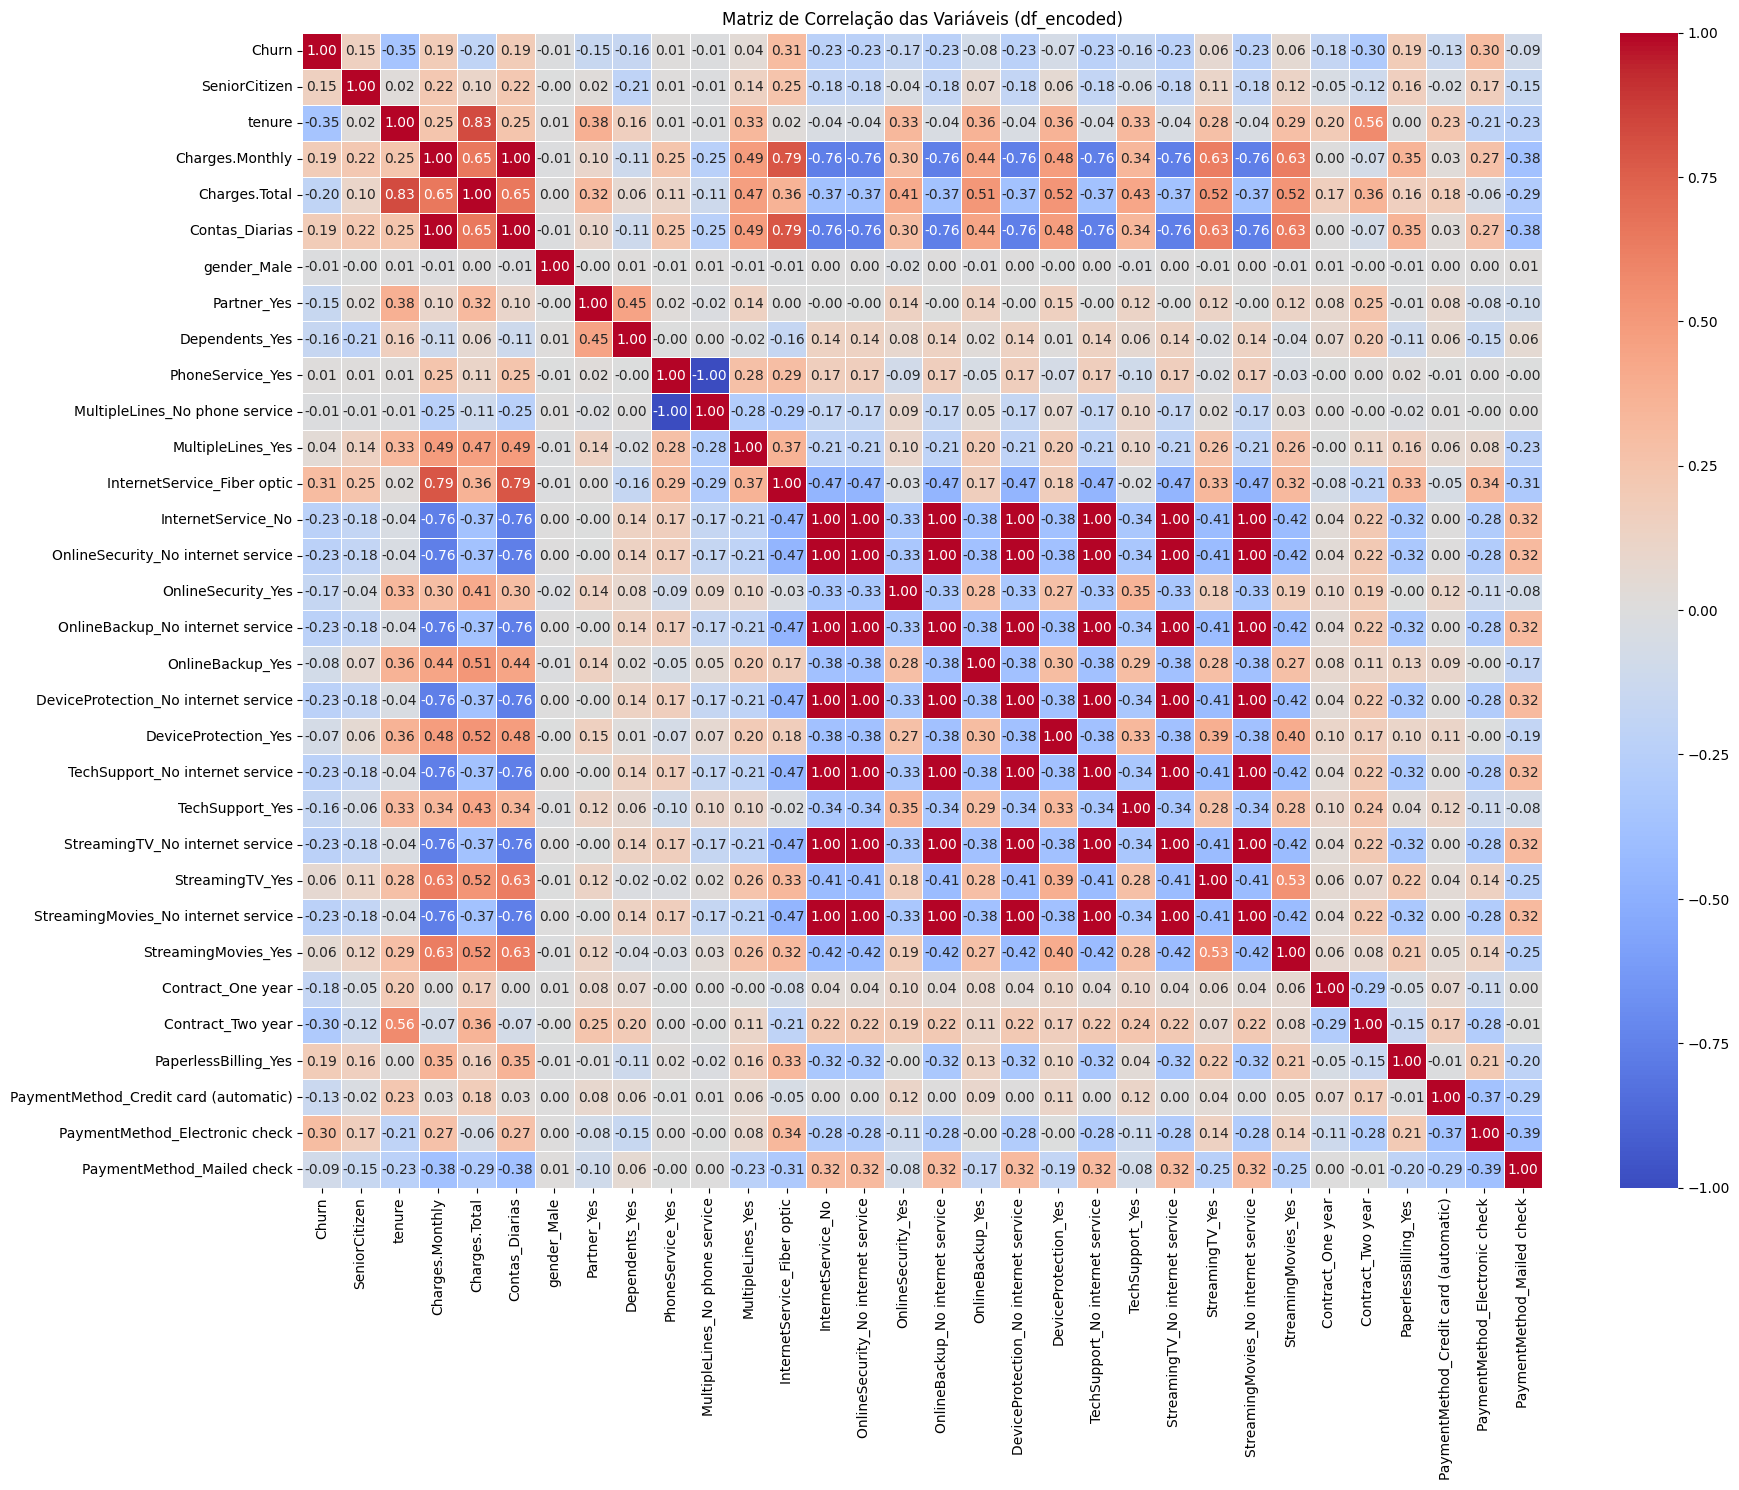

In [61]:
# Matriz de correlação
correlation = df_encoded.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Matriz de Correlação das Variáveis (df_encoded)')
plt.show()

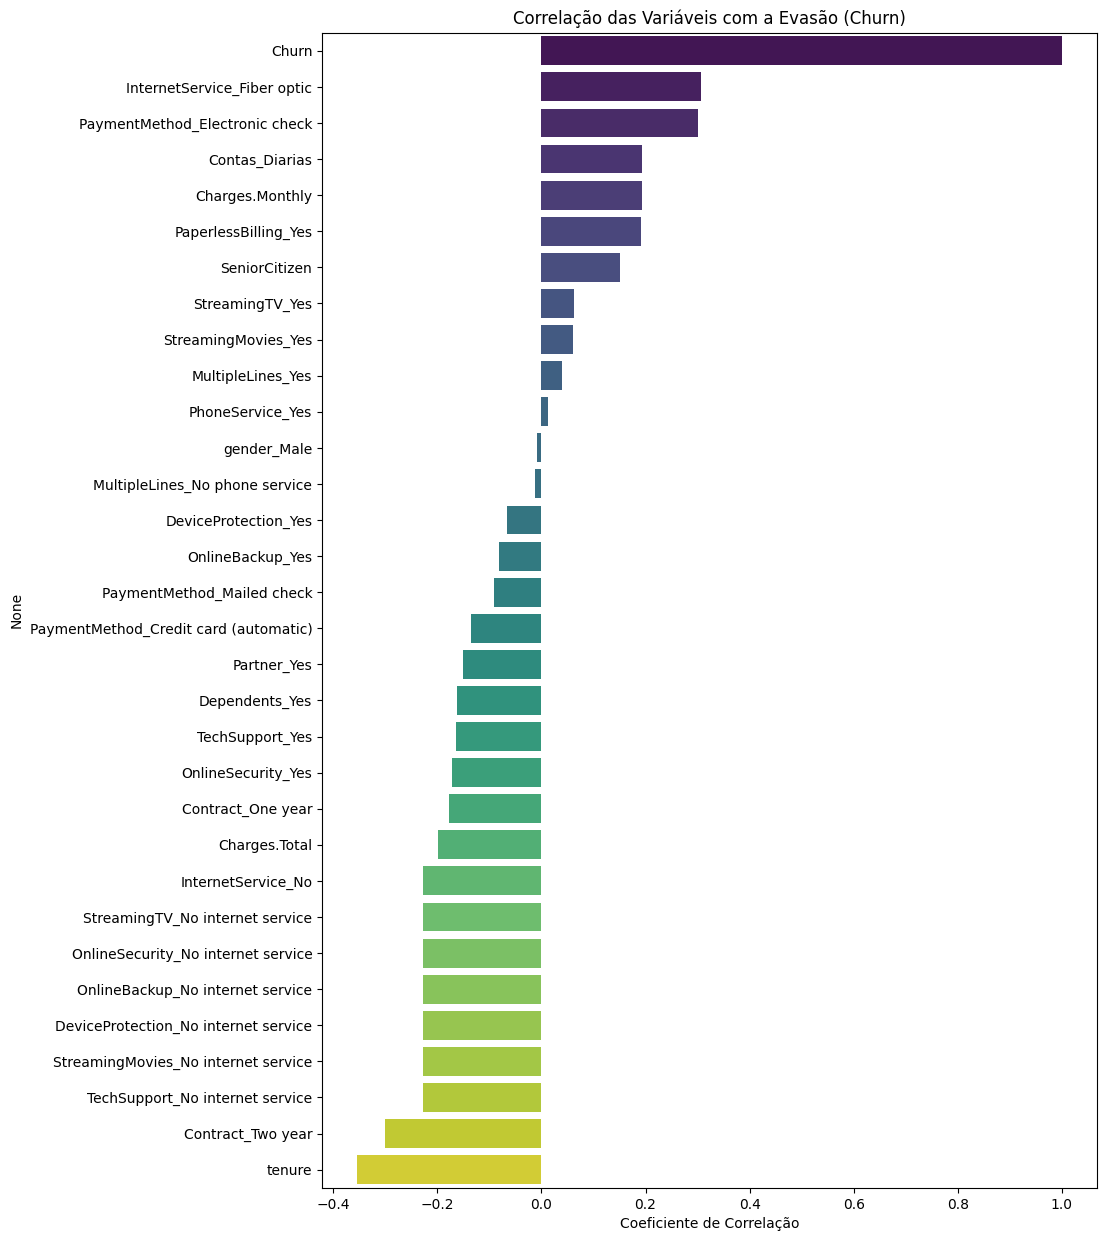

In [75]:
# Isolando a correlação apenas com a variável alvo
churn_corr = df_encoded.corr()['Churn'].sort_values(ascending=False)

plt.figure(figsize=(10, 15))
sns.barplot(
    x=churn_corr.values,
    y=churn_corr.index,
    hue=churn_corr.index,
    palette='viridis',
    legend=False
)
plt.title('Correlação das Variáveis com a Evasão (Churn)')
plt.xlabel('Coeficiente de Correlação')
plt.show()

As 5 variáveis que mais impactam o churn são: InternetService_Fiber optic, PaymentMethod_Electronic check, Contas_Diarias, Charges_Montly, PaperlessBilling.Yes

### Análises Direcionadas

### Tempo de contrato x Evasão

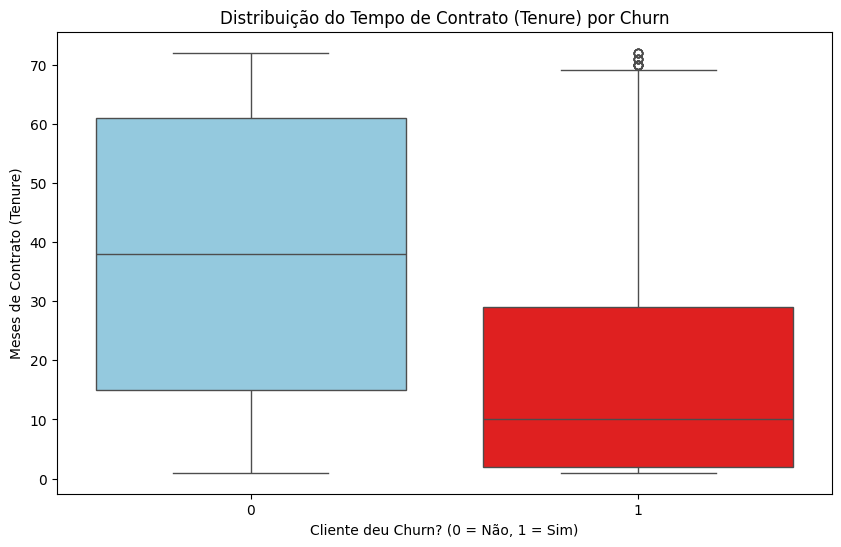

In [63]:
df_encoded['Churn'] = df_encoded['Churn'].astype('category')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df_encoded, hue='Churn',
            palette=['skyblue', 'red'], legend=False)

plt.title('Distribuição do Tempo de Contrato (Tenure) por Churn')
plt.xlabel('Cliente deu Churn? (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato (Tenure)')
plt.show()

### Total de gasto x Evasão

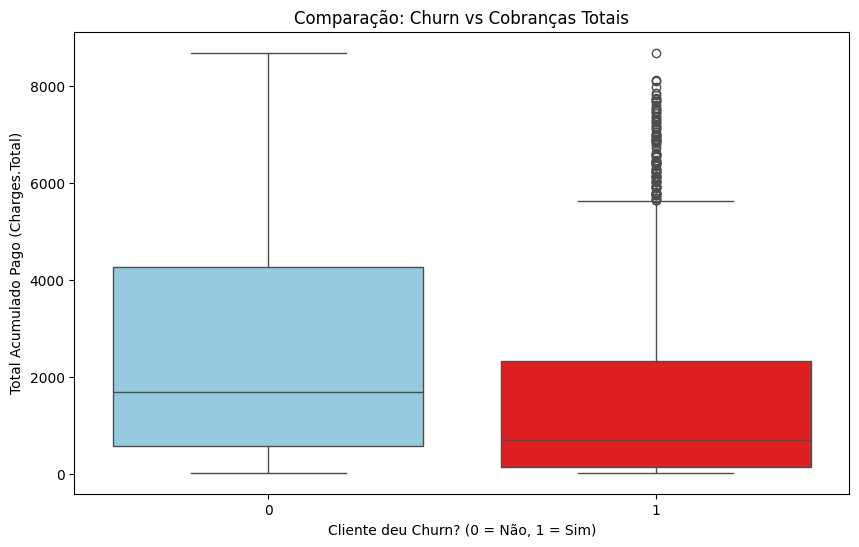

In [64]:
df_encoded['Charges.Total'] = pd.to_numeric(df_encoded['Charges.Total'], errors='coerce')

plt.figure(figsize=(10, 6))

cores_customizadas = {0: "skyblue", 1: "red"}

sns.boxplot(x='Churn', y='Charges.Total', data=df_encoded,
            hue='Churn', palette=cores_customizadas, legend=False)

plt.title('Comparação: Churn vs Cobranças Totais')
plt.xlabel('Cliente deu Churn? (0 = Não, 1 = Sim)')
plt.ylabel('Total Acumulado Pago (Charges.Total)')
plt.show()

# 🤖 Modelagem Preditiva

### Separação de dados

In [65]:
from sklearn.model_selection import train_test_split

x = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Dados divididos corretamente:")
print(f"Shape de x_treino: {x_treino.shape}") # (Entradas de treino)
print(f"Shape de x_teste: {x_teste.shape}")   # (Entradas de teste)
print(f"Shape de y_treino: {y_treino.shape}") # (Respostas de treino)
print(f"Shape de y_teste: {y_teste.shape}")   # (Respostas de teste)

Dados divididos corretamente:
Shape de x_treino: (5625, 31)
Shape de x_teste: (1407, 31)
Shape de y_treino: (5625,)
Shape de y_teste: (1407,)


In [66]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('smt', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

# Validando em 5 partes diferentes dos dados (Cross-Validation)
scoring = ['accuracy', 'recall', 'precision', 'f1']
cv_results = cross_validate(pipeline_lr, x, y, cv=5, scoring=scoring)

print(f"Recall Médio (CV): {cv_results['test_recall'].mean():.2f}")
print(f"F1-Score Médio (CV): {cv_results['test_f1'].mean():.2f}")

Recall Médio (CV): 0.64
F1-Score Médio (CV): 0.61


<Figure size 800x600 with 0 Axes>

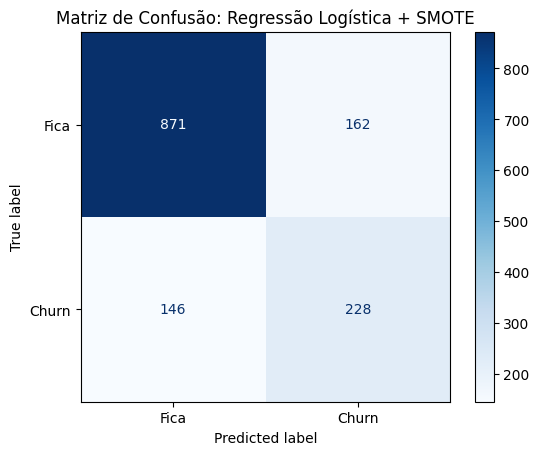

In [67]:
# --- Visualização do Desempenho ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Treinando o modelo no conjunto de treino completo para testar no conjunto de teste separado
pipeline_lr.fit(x_treino, y_treino)
y_pred = pipeline_lr.predict(x_teste)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fica', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão: Regressão Logística + SMOTE')
plt.show()

### Modelo Random Forest (sem SMOTE)

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_treino, y_treino)
y_pred_rf = rf_model.predict(x_teste)

print("--- Resultado Random Forest ---")
print(classification_report(y_teste, y_pred_rf))

--- Resultado Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



### Regressão Logística (sem SMOTE)

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Aplicação da normalização de dados para fazer a regressão logística
scaler = StandardScaler()
x_treino_scaled = scaler.fit_transform(x_treino)
x_teste_scaled = scaler.transform(x_teste)

# 3. Criar e treinar a Regressão Logística com os dados normalizados
lr_model = LogisticRegression(random_state=42)
lr_model.fit(x_treino_scaled, y_treino)

y_pred_lr = lr_model.predict(x_teste_scaled)

print("--- Resultado Regressão Logística ---")
print(classification_report(y_teste, y_pred_lr))

--- Resultado Regressão Logística ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



### Aplicando SMOTE

In [70]:
from imblearn.over_sampling import SMOTE

# Criando o balanceador
smt = SMOTE(random_state=42)

x_treino_res, y_treino_res = smt.fit_resample(x_treino, y_treino)

print(f"Antes do SMOTE: {y_treino.value_counts()}")
print(f"Depois do SMOTE: {y_treino_res.value_counts()}")

Antes do SMOTE: Churn
0    4130
1    1495
Name: count, dtype: int64
Depois do SMOTE: Churn
0    4130
1    4130
Name: count, dtype: int64


### Modelo Random Forest (com SMOTE)

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_bal = RandomForestClassifier(random_state=42)
rf_bal.fit(x_treino_res, y_treino_res)

y_pred_rf_bal = rf_bal.predict(x_teste)
print("--- Random Forest com SMOTE ---")
print(classification_report(y_teste, y_pred_rf_bal))

--- Random Forest com SMOTE ---
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.58      0.57      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.78      0.78      1407



### Regressão Logística (com SMOTE)

In [72]:
# 1. Normalizar os dados que acabaram de sair do SMOTE
scaler_res = StandardScaler()
x_treino_res_scaled = scaler_res.fit_transform(x_treino_res)

x_teste_scaled = scaler_res.transform(x_teste)

# 2. Treinar a Regressão Logística
lr_res = LogisticRegression(random_state=42)
lr_res.fit(x_treino_res_scaled, y_treino_res)

y_pred_lr_res = lr_res.predict(x_teste_scaled)
print("---Regressão Logística com SMOTE---")
print(classification_report(y_teste, y_pred_lr_res))

---Regressão Logística com SMOTE---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.61      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.78      0.78      0.78      1407



#Avaliação dos modelos
### Tabela Comparativa de Modelos

| Modelo | SMOTE | Acurácia | Precisão (Classe 1) | Recall (Classe 1) | F1-Score (Classe 1) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| Random Forest (Base) | Não | 0,78 | 0,62 | 0,46 | 0,53 |
| Regressão Logística (Base) | Não | 0,80 | 0,66 | 0,53 | 0,59 |
| Random Forest (SMOTE) | Sim | 0,78 | 0,58 | 0,57 | 0,57 |
| **Regressão Logística (SMOTE)** | **Sim** | **0,78** | **0,58** | **0,61** | **0,60** |

* O "Vencedor" por Equilíbrio: A Regressão Logística com SMOTE obteve o maior F1-Score (0,60) e o maior Recall (0,61). Isso significa que ele é o modelo mais eficiente em encontrar clientes que realmente pretendem sair (Churn), sem sacrificar demais a precisão.

* O "Vencedor" por Acurácia: A Regressão Logística (Base) obteve a maior acurácia (0,80). No entanto, em problemas de Churn, a acurácia é uma métrica secundária, pois ela ignora o fato de que o modelo está errando muito na detecção dos clientes que saem (Recall de apenas 0,53).

* O Impacto do SMOTE: Note que em ambos os modelos (RF e RL), a aplicação do SMOTE aumentou o Recall. Isso prova que o balanceamento de dados permitiu que os algoritmos "enxergassem" melhor as características dos clientes que cancelam o serviço.

* Conclusão sobre Underfitting/Overfitting:

  * Como os resultados de acurácia entre os modelos variam pouco (entre 78% e 80%), não há evidências de Underfitting grave.

  * Como o desempenho no conjunto de teste foi consistente e as métricas estão equilibradas, o risco de Overfitting foi controlado, especialmente na Regressão Logística, que é um modelo linear mais robusto à memorização de ruídos.


# 📋  Interpretação e Conclusões

### Análise de importância das variáveis

### Regressão Logística

Na Regressão Logística (lr_res): A análise foca nos coeficientes. Variáveis com valores positivos elevados indicam fatores que impulsionam diretamente o Churn. Como o modelo foi treinado com dados normalizados (StandardScaler), a magnitude desses coeficientes nos permite comparar diretamente o peso de cada variável, independentemente de sua unidade original.

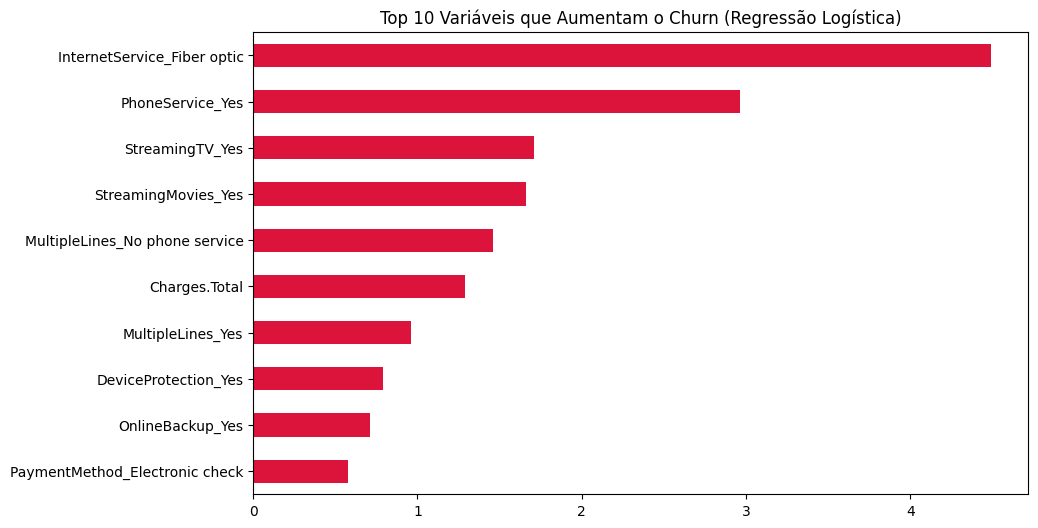

In [73]:
importancias_lr = pd.Series(lr_res.coef_[0], index=x.columns).sort_values(ascending=False)

top_10_importancias = importancias_lr.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10,6))
top_10_importancias.plot(kind='barh', color='crimson',)
plt.title('Top 10 Variáveis que Aumentam o Churn (Regressão Logística)')
plt.show()

### Random Forest
No Random Forest (lr_bal): A importância é medida pela redução da impureza de Gini. Diferente da Regressão Logística, que é um modelo linear, o Random Forest captura interações complexas e não lineares entre as variáveis (por exemplo, como a combinação de ser idoso e ter um contrato mensal potencializa o risco de saída).

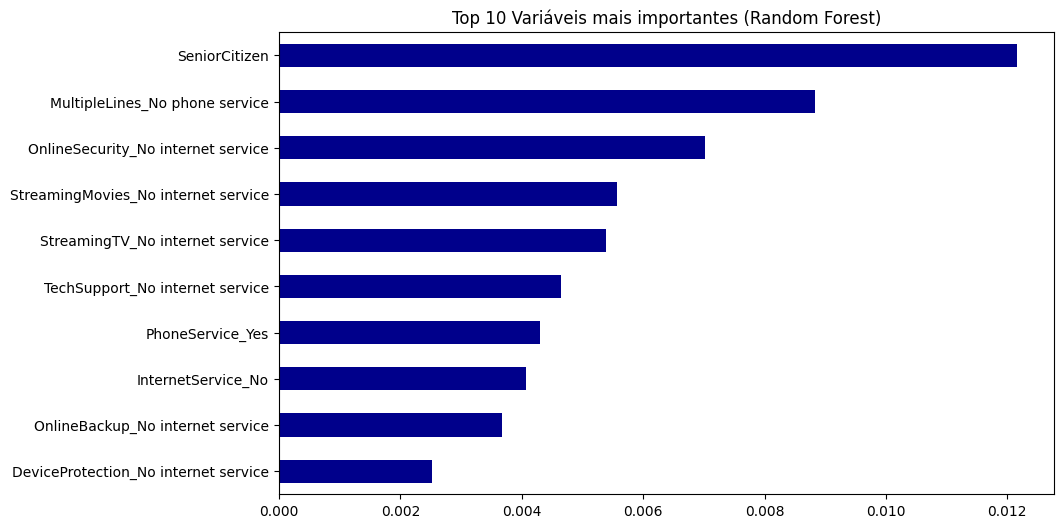

In [74]:
importancias_rf = pd.Series(rf_bal.feature_importances_, index=x.columns).sort_values(ascending=True)

plt.figure(figsize=(10,6))
importancias_rf.head(10).plot(kind='barh', color='darkblue')
plt.title('Top 10 Variáveis mais importantes (Random Forest)')
plt.show()

### Conclusão

1. Desempenho dos Modelos e Metodologia
* Para identificar os padrões de evasão, testamos dois algoritmos principais em quatro cenários diferentes. O uso da técnica SMOTE foi decisivo para equilibrar a base de dados, que originalmente possuía apenas 26% de casos de Churn.

* Modelo Vencedor: Regressão Logística com SMOTE.

* Justificativa: Apresentou o melhor equilíbrio (F1-Score: 0,60) e a maior capacidade de detecção (Recall: 0,61). A robustez desses resultados foi confirmada através de Validação Cruzada (K-Fold, k=5), que demonstrou a estabilidade das métricas em diferentes subconjuntos de dados, garantindo que o modelo possui alto poder de generalização. Isso significa que conseguimos identificar cerca de 6 em cada 10 clientes com probabilidade de churn, permitindo ações preventivas da equipe de retenção.

* Análise da Matriz de Confusão
  * Para validar a escolha da Regressão Logística com SMOTE, analisamos a Matriz de Confusão no conjunto de teste. O gráfico demonstra que o modelo foi bem-sucedido em equilibrar os erros:

  * Minimização de Falsos Negativos: Conseguimos capturar a maioria dos clientes em risco de evasão (Recall de 0,61), o que é o objetivo principal do projeto.

  * Gestão de Falsos Positivos: Embora o modelo classifique alguns clientes fiéis como possíveis churns, para a TelecomX_BR, o custo de uma ação preventiva (como um contato de fidelização ou oferta de desconto) é significativamente menor do que o custo de aquisição de um novo cliente (CAC) para substituir um que saiu.

2. Principais Fatores de Influência (Drivers de Churn)
* Com base nos coeficientes da Regressão Logística e na importância de variáveis do Random Forest, identificamos os três pilares que impulsionam a saída dos clientes:

  * Tipo de Contrato (Mensal):
    * Clientes com contratos de renovação mensal têm a maior probabilidade de evasão. A ausência de um compromisso de longo prazo facilita a migração para concorrentes.

  * Serviço de Internet (Fibra Ótica):
    * Surpreendentemente, a fibra ótica está associada a um maior Churn. Isso sugere que, embora seja uma tecnologia superior, pode haver problemas de estabilidade, preço elevado ou suporte técnico insuficiente nesta categoria.

  * Método de Pagamento (Electronic Check) e Faturamento Digital:
    * Clientes que utilizam processos manuais de pagamento (cheque eletrônico) e recebem faturas digitais são mais propensos a sair, possivelmente por estarem mais expostos a ofertas da concorrência no ambiente digital.

3. Fatores de Fidelização (Drivers de Retenção)
* Tempo de Casa (Tenure):
  * Quanto mais tempo o cliente permanece na empresa, menor a chance de ele sair.
  * Os primeiros 12 meses são os mais críticos.

* Contratos de Longo Prazo:
  * Clientes com contratos de 1 ou 2 anos apresentam taxas de Churn drasticamente menores.

4. Proposta de Estratégias de Retenção
* Com base nos dados, propomos as seguintes ações para a TelecomX_BR:

  * Migração de Contrato: Criar campanhas de incentivo (descontos ou upgrades de velocidade) para migrar clientes de contratos "Mensais" para contratos de "1 Ano".

  * Auditoria no Serviço de Fibra: Realizar uma investigação técnica e de satisfação específica com os usuários de fibra ótica para identificar se a evasão ocorre por falhas técnicas ou por preço desalinhado com o mercado.

   * Incentivo ao Débito Automático: Oferecer benefícios (ex: cashback ou bônus de dados) para clientes que trocarem o "Electronic Check" pelo débito automático, reduzindo a carga cognitiva mensal do pagamento.

  * Programa "Primeiro Ano": Implementar um programa de Customer Success intensivo para novos clientes nos primeiros 6 meses, período onde o risco de Churn é estatisticamente mais elevado.

5. Conclusão Técnica
* O modelo desenvolvido está pronto para ser integrado a um sistema de alerta. Ao aplicar o modelo à base de clientes atual, a equipe de marketing pode priorizar contatos com clientes que receberam o rótulo "Churn = 1", otimizando os custos de retenção e maximizando o Valor de Vida do Cliente (LTV).